# TASK 1: DATA UNDERSTANDING AND PREPROCESSING

In [1]:
#1. Import libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
#2. Load the datasets

In [4]:
Solutions = pd.read_excel("TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

Quant = pd.read_excel("TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")

Cat = pd.read_excel("TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")

fmri = pd.read_csv("TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

In [5]:
#3. Data Understanding

In [6]:
print("Solutions:", Solutions.shape)
print("Quantitative:", Quant.shape)
print("Categorical:", Cat.shape)
print("fMRI:", fmri.shape)

Solutions: (1213, 3)
Quantitative: (1213, 19)
Categorical: (1213, 10)
fMRI: (1213, 19901)


In [7]:
Solutions.head()

,participant_id,ADHD_Outcome,Sex_F
0,UmrK0vMLopoR,1,1
1,CPaeQkhcjg7d,1,0
2,Nb4EetVPm3gs,1,0
3,p4vPhVu91o4b,1,1
4,M09PXs7arQ5E,1,1


In [8]:
Quant.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [9]:
Cat.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [10]:
fmri.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
1,WHWymJu6zNZi,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
2,4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
3,obEacy4Of68I,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
4,s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273


In [11]:
Solutions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   participant_id  1213 non-null   object
 1   ADHD_Outcome    1213 non-null   int64 
 2   Sex_F           1213 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.6+ KB


In [12]:
Quant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1200 non-null   float64
 2   ColorVision_CV_Score        1190 non-null   float64
 3   APQ_P_APQ_P_CP              1201 non-null   float64
 4   APQ_P_APQ_P_ID              1201 non-null   float64
 5   APQ_P_APQ_P_INV             1201 non-null   float64
 6   APQ_P_APQ_P_OPD             1201 non-null   float64
 7   APQ_P_APQ_P_PM              1201 non-null   float64
 8   APQ_P_APQ_P_PP              1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems    1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total  1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems  1204 non-null   float64
 12  SDQ_SDQ_Externalizing       1204 non-null   float64
 13  SDQ_SDQ_Generating_Impact   1204 

In [13]:
Cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


In [14]:
fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Columns: 19901 entries, participant_id to 198throw_199thcolumn
dtypes: float64(19900), object(1)
memory usage: 184.2+ MB


In [15]:
#4. Identify Common ID and Target Variable

In [16]:
print(Solutions.columns)
print(Quant.columns)
print(Cat.columns)
print(fmri.columns[:10])

Index(['participant_id', 'ADHD_Outcome', 'Sex_F'], dtype='object')
Index(['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score',
       'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
       'MRI_Track_Age_at_Scan'],
      dtype='object')
Index(['participant_id', 'Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site',
       'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race',
       'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu',
       'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu',
       'Barratt_Barratt_P2_Occ'],
      dtype='object')
Index(['participant_id', '0throw_1thcolumn', '0throw_2thcolumn',
       '0throw_3thcolumn', '0t

In [17]:
Solutions['ADHD_Outcome'].value_counts()

ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

In [18]:
Solutions['ADHD_Outcome'].value_counts(normalize=True)*100

ADHD_Outcome
1    68.507832
0    31.492168
Name: proportion, dtype: float64

Data Preprocessing and Cleaning

In [19]:
Quant.isnull().sum()

participant_id                  0
EHQ_EHQ_Total                  13
ColorVision_CV_Score           23
APQ_P_APQ_P_CP                 12
APQ_P_APQ_P_ID                 12
APQ_P_APQ_P_INV                12
APQ_P_APQ_P_OPD                12
APQ_P_APQ_P_PM                 12
APQ_P_APQ_P_PP                 12
SDQ_SDQ_Conduct_Problems        9
SDQ_SDQ_Difficulties_Total      9
SDQ_SDQ_Emotional_Problems      9
SDQ_SDQ_Externalizing           9
SDQ_SDQ_Generating_Impact       9
SDQ_SDQ_Hyperactivity           9
SDQ_SDQ_Internalizing           9
SDQ_SDQ_Peer_Problems           9
SDQ_SDQ_Prosocial               9
MRI_Track_Age_at_Scan         360
dtype: int64

In [20]:
Cat.isnull().sum()

participant_id                        0
Basic_Demos_Enroll_Year               0
Basic_Demos_Study_Site                0
PreInt_Demos_Fam_Child_Ethnicity     43
PreInt_Demos_Fam_Child_Race          54
MRI_Track_Scan_Location               3
Barratt_Barratt_P1_Edu               15
Barratt_Barratt_P1_Occ               31
Barratt_Barratt_P2_Edu              198
Barratt_Barratt_P2_Occ              222
dtype: int64

In [21]:
Solutions.isnull().sum()

participant_id    0
ADHD_Outcome      0
Sex_F             0
dtype: int64

In [22]:
fmri.isnull().sum().sum()

np.int64(0)

In [23]:
Solutions.duplicated().sum()
Quant.duplicated().sum()
Cat.duplicated().sum()
fmri.duplicated().sum()

np.int64(0)

In [24]:
# Merge the datasets

In [25]:
df = Solutions.merge(Quant, on='participant_id', how='inner')

df = df.merge(Cat, on='participant_id', how='inner')

df = df.merge(fmri, on='participant_id', how='inner')

In [26]:
df.shape

(1213, 19930)

In [27]:
df.head()

,participant_id,ADHD_Outcome,Sex_F,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,UmrK0vMLopoR,1,1,40.00,13.0,3.0,10.0,47.0,13.0,11.0,...,0.073282,-0.044925,-0.057102,0.260735,0.458798,0.201057,0.207405,0.606301,0.586939,0.460227
1,CPaeQkhcjg7d,1,0,-94.47,14.0,3.0,13.0,34.0,18.0,23.0,...,0.138573,0.110515,-0.132631,-0.023360,0.572922,0.572254,0.436960,0.570057,0.565683,0.718430
2,Nb4EetVPm3gs,1,0,-46.67,14.0,4.0,10.0,35.0,16.0,10.0,...,0.124581,-0.034945,0.058824,0.092067,0.429785,0.387289,0.328993,0.637749,0.108923,0.149962
3,p4vPhVu91o4b,1,1,-26.68,10.0,5.0,12.0,39.0,19.0,16.0,...,-0.081272,-0.192391,-0.246083,-0.178243,0.747706,0.601304,0.617073,0.728884,0.604767,0.848008
4,M09PXs7arQ5E,1,1,0.00,14.0,5.0,15.0,40.0,20.0,24.0,...,-0.082429,-0.131800,-0.345580,-0.211020,0.608721,0.316845,0.291920,0.481148,0.494580,0.716663


In [28]:
df.isnull().sum().sort_values(ascending=False)

MRI_Track_Age_at_Scan               360
Barratt_Barratt_P2_Occ              222
Barratt_Barratt_P2_Edu              198
PreInt_Demos_Fam_Child_Race          54
PreInt_Demos_Fam_Child_Ethnicity     43
                                   ... 
Basic_Demos_Enroll_Year               0
Basic_Demos_Study_Site                0
192throw_198thcolumn                  0
192throw_199thcolumn                  0
128throw_193thcolumn                  0
Length: 19930, dtype: int64

In [29]:
# Missing Value Summary Table

In [30]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df.sort_values(by='Missing Percentage', ascending=False).head(20)

,Missing Count,Missing Percentage
MRI_Track_Age_at_Scan,360,29.678483
Barratt_Barratt_P2_Occ,222,18.301731
Barratt_Barratt_P2_Edu,198,16.323166
PreInt_Demos_Fam_Child_Race,54,4.451772
PreInt_Demos_Fam_Child_Ethnicity,43,3.544930
Barratt_Barratt_P1_Occ,31,2.555647
ColorVision_CV_Score,23,1.896125
Barratt_Barratt_P1_Edu,15,1.236603
EHQ_EHQ_Total,13,1.071723
APQ_P_APQ_P_INV,12,0.989283


In [31]:
# Identify Data Type

In [32]:
df.dtypes.value_counts()

float64    19925
int64          4
object         1
Name: count, dtype: int64

In [33]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))

Categorical Features: 1
Numerical Features: 19929


In [34]:
print(categorical_cols)

['participant_id']


In [35]:
df = df.drop('participant_id', axis=1)

In [36]:
df.shape

(1213, 19929)

In [37]:
# Separate Target and Features

In [38]:
X = df.drop('ADHD_Outcome', axis=1)

y = df['ADHD_Outcome']

In [39]:
print(X.shape)
print(y.shape)

(1213, 19928)
(1213,)


In [40]:
# Handle Missing Values, Outliers and inconsistencies

In [41]:
num_imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    num_imputer.fit_transform(X),
    columns=X.columns
)

In [42]:
X_imputed.isnull().sum().sum()

np.int64(0)

In [43]:
metadata_cols = [
    'EHQ_EHQ_Total',
    'ColorVision_CV_Score',
    'APQ_P_APQ_P_CP',
    'APQ_P_APQ_P_ID',
    'APQ_P_APQ_P_INV',
    'APQ_P_APQ_P_OPD',
    'APQ_P_APQ_P_PM',
    'APQ_P_APQ_P_PP',
    'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Difficulties_Total',
    'SDQ_SDQ_Emotional_Problems',
    'SDQ_SDQ_Externalizing',
    'SDQ_SDQ_Generating_Impact',
    'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Internalizing',
    'SDQ_SDQ_Peer_Problems',
    'SDQ_SDQ_Prosocial',
    'MRI_Track_Age_at_Scan'
]

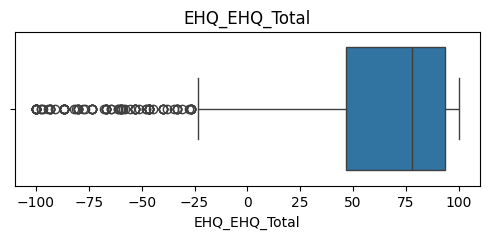

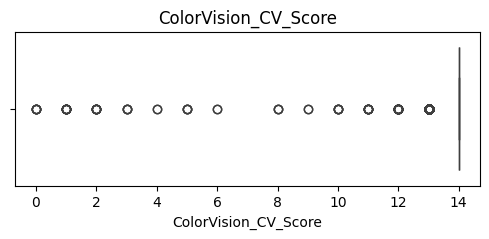

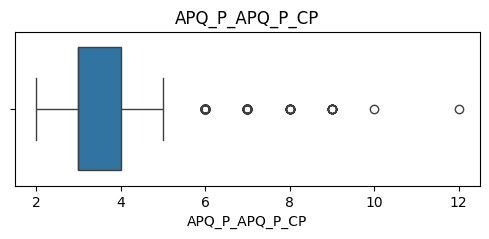

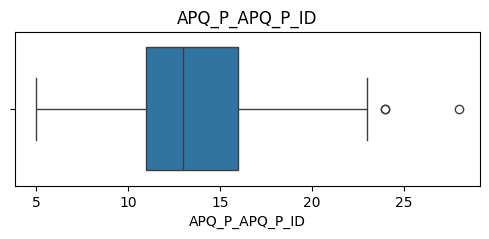

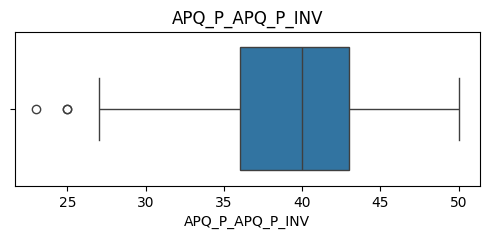

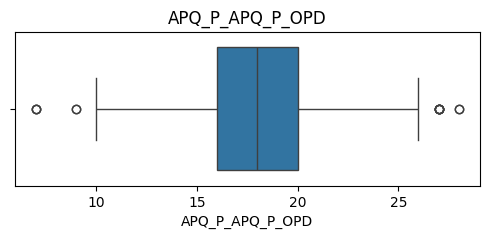

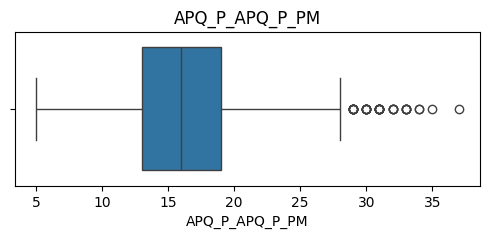

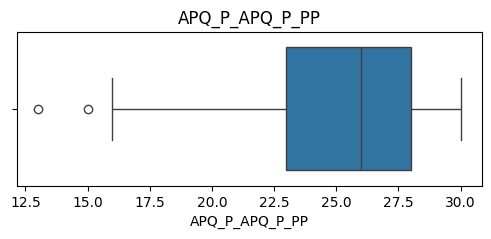

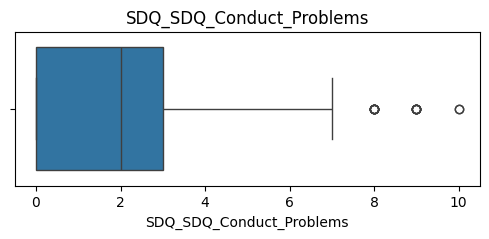

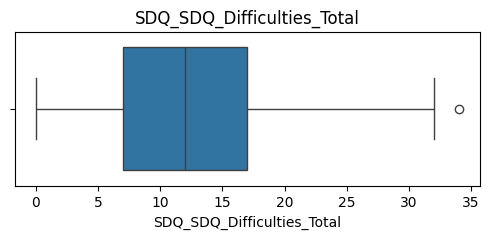

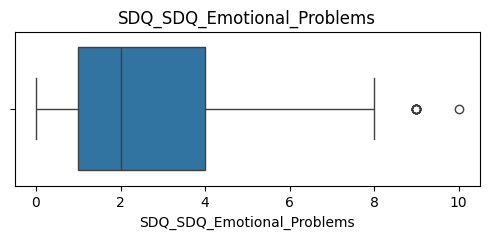

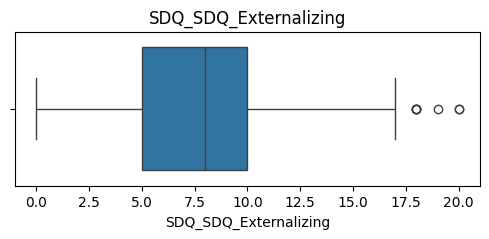

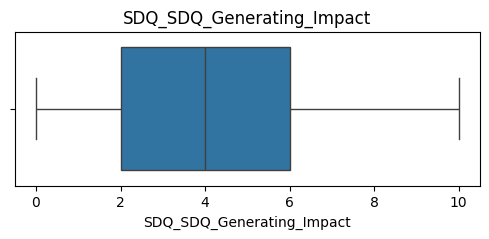

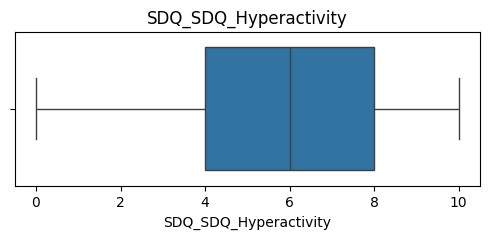

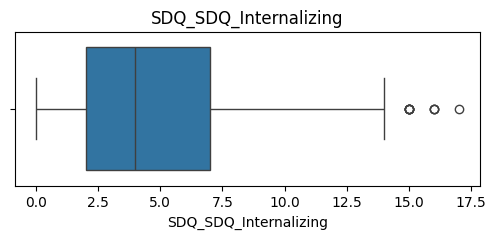

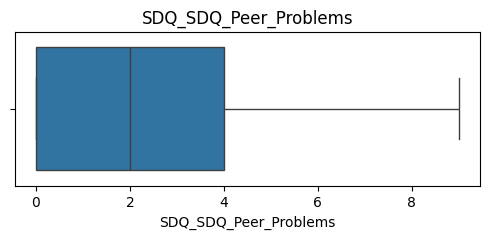

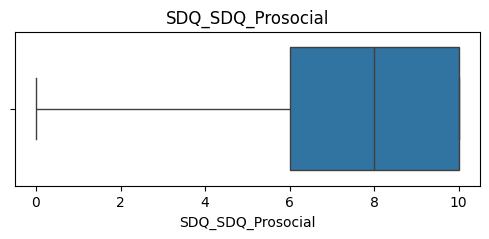

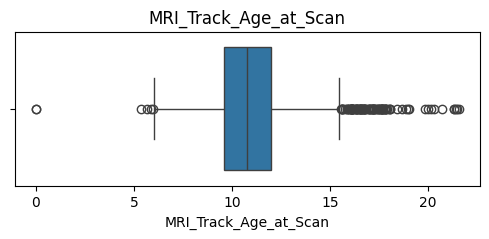

In [44]:
for col in metadata_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=X_imputed[col])
    plt.title(col)
    plt.show()

In [45]:
outlier_summary = {}

for col in metadata_cols:
    Q1 = X_imputed[col].quantile(0.25)
    Q3 = X_imputed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X_imputed[col] < lower) | (X_imputed[col] > upper)).sum()

    outlier_summary[col] = outliers

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=['Feature', 'Outlier_Count']
)

outlier_df.sort_values(
    by='Outlier_Count',
    ascending=False
)

,Feature,Outlier_Count
1,ColorVision_CV_Score,221
2,APQ_P_APQ_P_CP,127
0,EHQ_EHQ_Total,110
17,MRI_Track_Age_at_Scan,106
6,APQ_P_APQ_P_PM,37
8,SDQ_SDQ_Conduct_Problems,17
5,APQ_P_APQ_P_OPD,13
10,SDQ_SDQ_Emotional_Problems,11
14,SDQ_SDQ_Internalizing,10
11,SDQ_SDQ_Externalizing,7


In [46]:
#Feature Engineering and Dimensionality Reduction

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [48]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [49]:
print("Original Shape:", X_scaled.shape)

print("PCA Shape:", X_pca.shape)

Original Shape: (1213, 19928)
PCA Shape: (1213, 910)


In [50]:
X_final = pd.DataFrame(X_pca)

X_final['ADHD_Outcome'] = y.values

In [51]:
X_final.to_csv('ADHD_Preprocessed_Data.csv', index=False)

In [ ]:
# Create clean dataset 
clean_df = X_imputed.copy()

# Add target variable
clean_df['ADHD_Outcome'] = y.values

# Save clean dataset
clean_df.to_csv('ADHD_Clean_Dataset.csv', index=False)

print(clean_df.shape)

# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)


2.1 DESCRIPTIVE ANALYTICS

In [55]:
# Plot 1: Distribution of ADHD Diagnosis

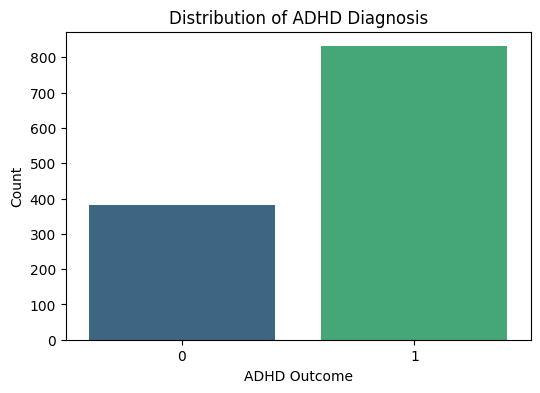

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='ADHD_Outcome',
    data=df,
    hue='ADHD_Outcome',
    palette='viridis',
    legend=False
)
plt.title('Distribution of ADHD Diagnosis')
plt.xlabel('ADHD Outcome')
plt.ylabel('Count')
plt.show()

In [57]:
# Plot 2: Age Distribution by ADHD Outcome

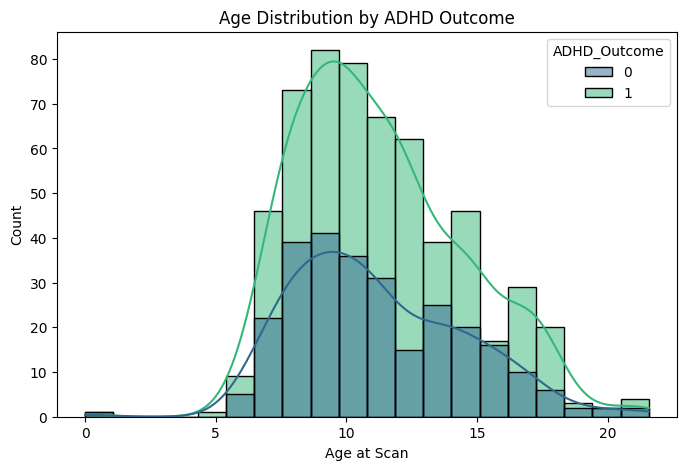

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MRI_Track_Age_at_Scan',
    hue='ADHD_Outcome',
    kde=True,
    bins=20,
    palette='viridis'
)

plt.title('Age Distribution by ADHD Outcome')
plt.xlabel('Age at Scan')
plt.ylabel('Count')
plt.show()


In [59]:
# Plot 3: ADHD Diagnosis Percentage by Age Group

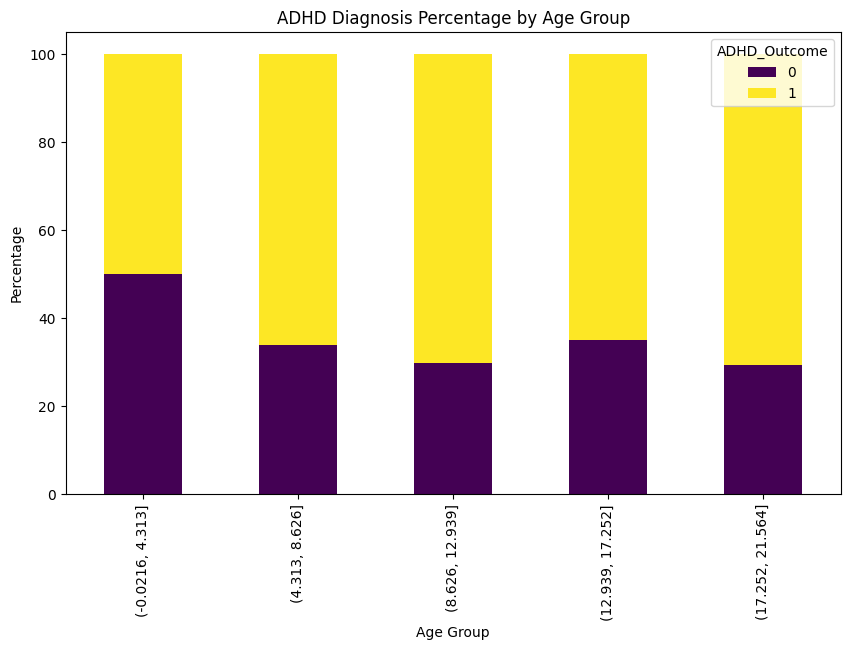

In [60]:
# Create age groups 
age_group = pd.cut(
    df['MRI_Track_Age_at_Scan'],
    bins=5
)

# Calculate ADHD percentages within each age group
adhd_age = pd.crosstab(
    age_group,
    df['ADHD_Outcome'],
    normalize='index'
) * 100

# Plot
adhd_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title('ADHD Diagnosis Percentage by Age Group')
plt.ylabel('Percentage')
plt.xlabel('Age Group')
plt.show()


2.2 DIAGNOSTIC ANALYTICS

In [61]:
# Plot 4: Hyperactivity Score by ADHD Diagnosis

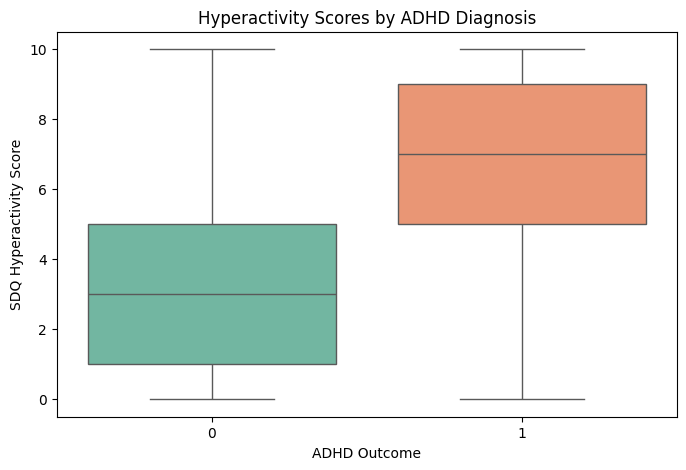

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='ADHD_Outcome',
    y='SDQ_SDQ_Hyperactivity',
    hue='ADHD_Outcome',
    data=df,
    palette='Set2',
    legend=False
)
plt.title('Hyperactivity Scores by ADHD Diagnosis')
plt.xlabel('ADHD Outcome')
plt.ylabel('SDQ Hyperactivity Score')
plt.show()

In [63]:
# Plot 5: ADHD Diagnosis by Sex

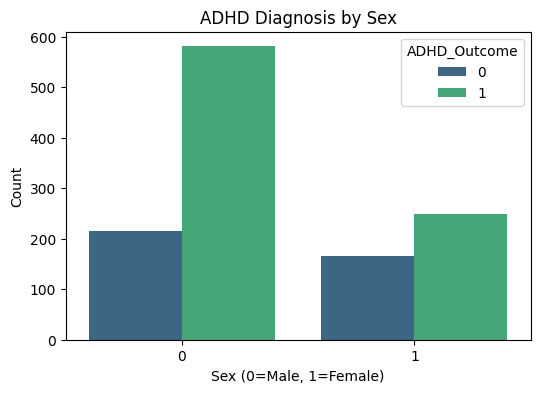

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex_F',
    hue='ADHD_Outcome',
    data=df,
    palette='viridis'
)

plt.title('ADHD Diagnosis by Sex')
plt.xlabel('Sex (0=Male, 1=Female)')
plt.ylabel('Count')

plt.show()

In [65]:
# Plot 6: Correlation Heatmap of Key Behavioural Features

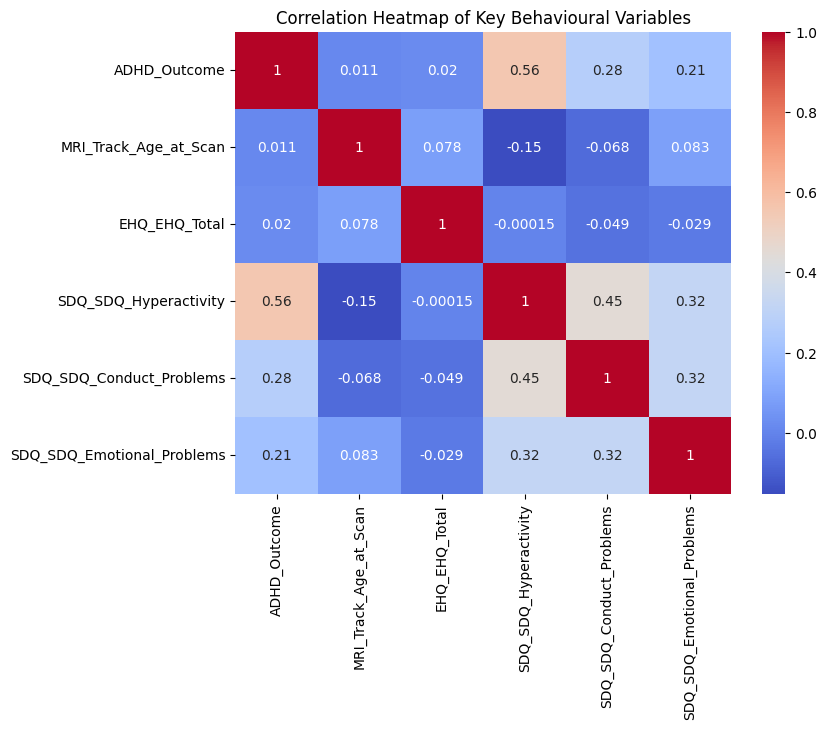

In [66]:
selected_cols = [
    'ADHD_Outcome',
    'MRI_Track_Age_at_Scan',
    'EHQ_EHQ_Total',
    'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Emotional_Problems'
]

corr = df[selected_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap of Key Behavioural Variables')
plt.show()

# HYPOTHESIS TESTING

 STATISTICAL HYPOTHESIS TESTING

In [67]:
#Hypothesis 1: Hyperactivity Scores
# H₀ : There is no significant difference in SDQ Hyperactivity scores between ADHD and non-ADHD participants.
# H₁ : There is a significant difference.

In [68]:
from scipy.stats import ttest_ind

adhd = df[df['ADHD_Outcome']==1]['SDQ_SDQ_Hyperactivity'].dropna()
non_adhd = df[df['ADHD_Outcome']==0]['SDQ_SDQ_Hyperactivity'].dropna()

t_stat, p_value = ttest_ind(
    adhd,
    non_adhd,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 23.074265844432126
P-value: 2.8925556546974317e-88


In [69]:
#Hypothesis 2: Emotional Problems
# H₀ : There is no significant difference in emotional problem scores between ADHD and non-ADHD participants.
# H₁ : There is a significant difference.

In [70]:
adhd = df[df['ADHD_Outcome']==1]['SDQ_SDQ_Emotional_Problems'].dropna()
non_adhd = df[df['ADHD_Outcome']==0]['SDQ_SDQ_Emotional_Problems'].dropna()

t_stat, p_value = ttest_ind(
    adhd,
    non_adhd,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 7.7628740414755155
P-value: 2.366716872461797e-14


In [71]:
#Hypothesis 3: Sex and ADHD
# H₀ : Sex and ADHD diagnosis are independent.
# H₁ : Sex and ADHD diagnosis are associated.

In [72]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['Sex_F'],
    df['ADHD_Outcome']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 20.17519467023486
P-value: 7.066334091845868e-06


#  TASK 3: MODEL DEVELOPMENT

PREDICTIVE ANALYTICS

In [73]:
# Define X and Y

In [74]:
X = df.drop('ADHD_Outcome', axis=1)
y = df['ADHD_Outcome']

In [75]:
# Train test split

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(970, 19928)
(243, 19928)


In [77]:
# Missing Value Imputation

In [78]:
imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print(X_train_imputed.isnull().sum().sum())
print(X_test_imputed.isnull().sum().sum())

0
0


In [79]:
# Standardization

In [80]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [81]:
# Feature Selection

In [82]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=300
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

print(X_train_selected.shape)
print(X_test_selected.shape)

(970, 300)
(243, 300)


In [83]:
# Hyperparameter Tuning with GridSearchCV

In [84]:
# LOGISTIC REGRESSION

In [85]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_LR = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_LR.fit(X_train_selected, y_train)

print("Best Parameters:", grid_LR.best_params_)
print("Best Cross-Validated ROC-AUC:", grid_LR.best_score_)

Best Parameters: {'C': 0.01}
Best Cross-Validated ROC-AUC: 0.859829902625416


In [84]:
best_lr = grid_LR.best_estimator_

y_pred_lr = best_lr.predict(X_test_selected)

y_prob_lr = best_lr.predict_proba(X_test_selected)[:,1]

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(y_test, y_pred, y_prob):

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

lr_results = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

print(lr_results)

{'Accuracy': 0.7860082304526749, 'Precision': 0.796875, 'Recall': 0.9216867469879518, 'F1 Score': 0.8547486033519553, 'ROC-AUC': 0.80355186981693}


In [86]:
# RANDOM FOREST

In [87]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_RF = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_RF.fit(X_train_selected, y_train)

print("Best Parameters:", grid_RF.best_params_)
print("Best CV ROC-AUC:", grid_RF.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.8577591519783064


In [88]:
best_rf = grid_RF.best_estimator_

y_pred_rf = best_rf.predict(X_test_selected)
y_prob_rf = best_rf.predict_proba(X_test_selected)[:,1]

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf
)

print(rf_results)

{'Accuracy': 0.7654320987654321, 'Precision': 0.7632850241545893, 'Recall': 0.9518072289156626, 'F1 Score': 0.8471849865951743, 'ROC-AUC': 0.7940854326396494}


In [89]:
# GRADIENT BOOSTING CLASSIFIER

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_GB = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_GB.fit(X_train_selected, y_train)

print("Best Parameters:", grid_GB.best_params_)
print("Best CV ROC-AUC:", grid_GB.best_score_)

In [ ]:
best_gb = grid_GB.best_estimator_

y_pred_gb = best_gb.predict(X_test_selected)
y_prob_gb = best_gb.predict_proba(X_test_selected)[:,1]

gb_results = evaluate_model(
    y_test,
    y_pred_gb,
    y_prob_gb
)

print(gb_results)

In [ ]:
# NEURAL NETWORK

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100,50)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

grid_MLP = GridSearchCV(
    MLPClassifier(
        max_iter=1000,
        random_state=42
    ),
    param_grid_mlp,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_MLP.fit(X_train_selected, y_train)

print("Best Parameters:", grid_MLP.best_params_)
print("Best CV ROC-AUC:", grid_MLP.best_score_)

In [ ]:
best_mlp = grid_MLP.best_estimator_

y_pred_mlp = best_mlp.predict(X_test_selected)
y_prob_mlp = best_mlp.predict_proba(X_test_selected)[:,1]

mlp_results = evaluate_model(
    y_test,
    y_pred_mlp,
    y_prob_mlp
)

print(mlp_results)

In [ ]:
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_XGB = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_XGB.fit(X_train_selected, y_train)

print("Best Parameters:", grid_XGB.best_params_)
print("Best CV ROC-AUC:", grid_XGB.best_score_)

In [ ]:
best_xgb = grid_XGB.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_selected)
y_prob_xgb = best_xgb.predict_proba(X_test_selected)[:,1]

xgb_results = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

print(xgb_results)

In [ ]:
# COMPARISON TABLE

In [ ]:
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_results,
    'Random Forest': rf_results,
    'Gradient Boosting': gb_results,
    'Neural Network': mlp_results,
    'XGBoost': xgb_results
}).T

comparison_df

In [ ]:
# CONFUSION MATRICES

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15,10))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Logistic Regression')

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens', ax=axes[0,1])
axes[0,1].set_title('Random Forest')

# Gradient Boosting
sns.heatmap(confusion_matrix(y_test, y_pred_gb),
            annot=True, fmt='d', cmap='Oranges', ax=axes[0,2])
axes[0,2].set_title('Gradient Boosting')

# Neural Network
sns.heatmap(confusion_matrix(y_test, y_pred_mlp),
            annot=True, fmt='d', cmap='Purples', ax=axes[1,0])
axes[1,0].set_title('Neural Network')

# XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Reds', ax=axes[1,1])
axes[1,1].set_title('XGBoost')

# Remove empty subplot
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

In [ ]:
# ROC CURVES

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})'
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(
    fpr_gb,
    tpr_gb,
    linewidth=2,
    label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})'
)

# Neural Network
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
plt.plot(
    fpr_mlp,
    tpr_mlp,
    linewidth=2,
    label=f'Neural Network (AUC = {roc_auc_score(y_test, y_prob_mlp):.3f})'
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})'
)

# Random classifier line
plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for ADHD Classification Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

# TASK 4: MODEL INTERPRETATION

In [ ]:
# Feature Importance Analysis

In [ ]:
selected_features = X_train.columns[selector.get_support()]

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

In [ ]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 20 Features from XGBoost')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
explainer = LimeTabularExplainer(
    training_data=X_train_selected,
    feature_names=selected_features,
    class_names=['Non-ADHD', 'ADHD'],
    mode='classification'
)

In [ ]:
i = 0

exp = explainer.explain_instance(
    X_test_selected[i],
    best_xgb.predict_proba,
    num_features=10
)

In [ ]:
exp.show_in_notebook(show_table=True)

In [ ]:
probs = best_xgb.predict_proba(X_test_selected)[:,1]

# Highest confidence ADHD prediction
i = np.argmax(probs)

exp = explainer.explain_instance(
    X_test_selected[i],
    best_xgb.predict_proba,
    num_features=15
)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()